# Clustering (Unsupervised Language Grouping)

This notebook covers the **Clustering** part of the assignment:

- Apply **at least two** clustering algorithms (e.g., **K-Means** and **Hierarchical/DBSCAN/GMM**)
- Choose an **optimal number of clusters (k)** using **Elbow** and/or **Silhouette**
- **Visualize** clusters in 2D using **PCA** (and optionally t-SNE)
- Report **Silhouette Score**
- Analyze **cluster composition/purity** (using true labels *only for analysis*, not for training)

It assumes you have the same feature table used in classification (CSV/Parquet/JSONL).


## 0) Setup

If needed:

```bash
pip install -U numpy pandas scikit-learn matplotlib joblib
```


In [46]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score



## 1) Load extracted features

Expected columns:
- numeric feature columns (MFCC stats, centroid, zcr, chroma, contrast, ...)
- `label` (language) — used ONLY for analyzing cluster purity/composition
- optional metadata columns like `filename`, `gender`


In [ ]:
# CONFIG
DATA_PATH = Path("processed_features_dataset.csv")
label_col = "label"
DROP_COLS_ALWAYS = ["filename", "gender"]

RANDOM_STATE = 42

# Preprocessing options
USE_PCA_FOR_CLUSTERING = True
PCA_VARIANCE_TO_KEEP = 0.95

# Search range for k (for KMeans / Agglomerative / GMM)
K_RANGE = range(2, 12)

RUN_TSNE = False
TSNE_MAX_POINTS = 3000  # subsample for speed if dataset is large


In [ ]:
def load_feature_table(path: Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path.resolve()}\n"
            "Put your extracted feature table next to this notebook, or update DATA_PATH."
        )
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)

df = load_feature_table(DATA_PATH)
print(df.shape)
df.head()


(10852, 51)


,mfcc_1_mean,mfcc_1_var,mfcc_2_mean,mfcc_2_var,mfcc_3_mean,mfcc_3_var,mfcc_4_mean,mfcc_4_var,mfcc_5_mean,mfcc_5_var,...,centroid_var,zcr_mean,zcr_var,chroma_mean,chroma_var,contrast_mean,contrast_var,label,gender,filename
0,-263.92203,18606.697,77.982285,3757.3372,-9.310464,984.79010,39.328022,945.08030,5.222437,355.08865,...,1.277559e+06,0.127055,0.007808,0.395074,0.095600,23.148505,163.087572,German,Male,810100147_male_german_voice02.mp3
1,-349.74377,26918.447,63.186960,3615.7522,-9.667652,981.03674,50.941124,904.13910,11.845338,385.06332,...,1.027629e+06,0.124588,0.008629,0.368092,0.102901,24.040477,160.237843,German,Male,810100147_male_german_voice02.mp3
2,-245.28510,19061.607,73.344010,3277.5037,-8.776618,1122.65160,47.934100,1196.81510,7.272524,265.86210,...,1.245263e+06,0.114661,0.009235,0.352566,0.099449,23.742645,158.019540,German,Male,810100147_male_german_voice02.mp3
3,-318.25030,27300.646,68.638030,4238.5645,3.514310,799.79070,29.387894,834.46576,-0.657580,582.34360,...,1.787097e+06,0.127870,0.009768,0.412828,0.093851,23.488550,153.645357,German,Male,810100147_male_german_voice02.mp3
4,-339.06280,33127.367,71.513080,4391.4937,-1.589328,1419.51620,25.225393,737.10250,0.498458,531.27940,...,1.657907e+06,0.120823,0.009985,0.391374,0.098067,24.110493,149.460309,German,Male,810100147_male_german_voice02.mp3


In [49]:
print("Label column:", label_col)
print("Classes:", sorted(df[label_col].astype(str).unique().tolist()))


Label column: label
Classes: ['German', 'Italian', 'Korean', 'Spanish']


In [ ]:
drop_cols = [label_col] + [c for c in DROP_COLS_ALWAYS if c in df.columns]
X_df = df.drop(columns=drop_cols, errors="ignore")

numeric_cols = X_df.select_dtypes(include=["number"]).columns.tolist()
if len(numeric_cols) == 0:
    raise ValueError("No numeric feature columns found. Ensure extracted features are numeric.")

X_df = X_df[numeric_cols].copy()
y_true = df[label_col].astype(str).copy()

print("X shape:", X_df.shape)
print("Using #features:", len(numeric_cols))
print("Dropped columns:", drop_cols)


X shape: (10852, 48)
Using #features: 48
Dropped columns: ['label', 'filename', 'gender']


## 2) Preprocess (impute + scale + optional PCA)

Clustering is distance-based for many algorithms, so scaling is important.


In [51]:
def make_preprocessor(use_pca: bool) -> Pipeline:
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
    if use_pca:
        steps.append(("pca", PCA(n_components=PCA_VARIANCE_TO_KEEP, svd_solver="full", random_state=RANDOM_STATE)))
    return Pipeline(steps)

preprocess = make_preprocessor(USE_PCA_FOR_CLUSTERING)

X = preprocess.fit_transform(X_df)
print("Transformed X shape:", X.shape)


Transformed X shape: (10852, 32)


## 3) Helper functions: clustering metrics + purity

Required: **Silhouette score**.  
Useful extras: Calinski–Harabasz, Davies–Bouldin.

Purity uses true labels only for *analysis*, not for fitting.


In [ ]:
def clustering_metrics(X, cluster_labels):
    unique = np.unique(cluster_labels)
    if len(unique) < 2:
        return {"silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan}

    mask = cluster_labels != -1
    if mask.sum() < 2 or len(np.unique(cluster_labels[mask])) < 2:
        sil = np.nan
    else:
        sil = silhouette_score(X[mask], cluster_labels[mask])

    return {
        "silhouette": sil,
        "calinski_harabasz": calinski_harabasz_score(X, cluster_labels),
        "davies_bouldin": davies_bouldin_score(X, cluster_labels),
    }

def cluster_purity(y_true, cluster_labels):
    mask = cluster_labels != -1
    y = y_true[mask]
    c = cluster_labels[mask]

    if len(y) == 0:
        return np.nan, pd.DataFrame()

    ct = pd.crosstab(pd.Series(c, name="cluster"), pd.Series(y, name="label"))
    purity = (ct.max(axis=1).sum()) / ct.values.sum()
    return purity, ct

def plot_pca_2d(X, labels, title):
    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    X2 = pca2.fit_transform(X)

    plt.figure()
    plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=12, alpha=0.7)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    return pca2.explained_variance_ratio_.sum()


## 4) K-Means: choose k (Elbow + Silhouette)

We sweep k and plot:
- **Inertia** (Elbow method)
- **Silhouette** (higher is better)


In [53]:
k_results = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels_km = km.fit_predict(X)

    m = clustering_metrics(X, labels_km)
    k_results.append({
        "k": k,
        "inertia": km.inertia_,
        **m
    })

k_df = pd.DataFrame(k_results)
k_df


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,425722.253733,0.139511,1791.003145,2.388226
1,3,384398.773799,0.138849,1574.824157,2.331085
2,4,345177.048837,0.155198,1579.946284,2.035056
3,5,314991.151119,0.181846,1558.269730,1.857965
4,6,292823.071867,0.181538,1505.082474,1.867099
5,7,276812.650613,0.194848,1431.198456,1.806876
6,8,262993.007673,0.200574,1372.488973,1.740044
7,9,251720.587171,0.204876,1315.286691,1.707331
8,10,239696.800721,0.212128,1288.106713,1.646034
9,11,229410.269366,0.222093,1259.775998,1.590019


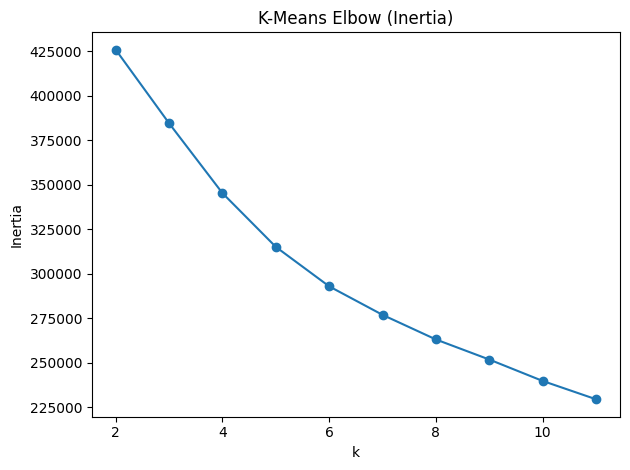

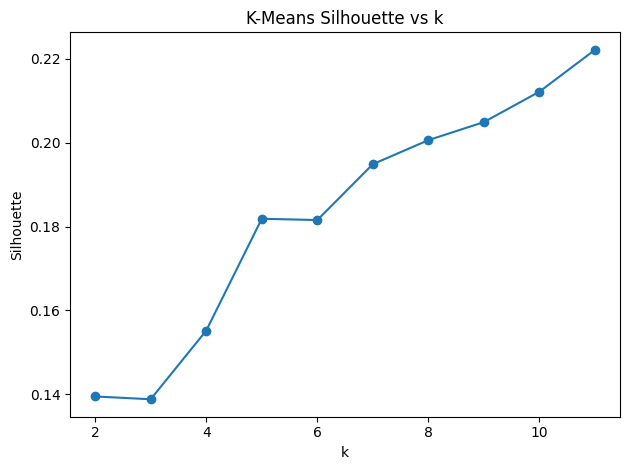

Best k by silhouette: 11


In [54]:
# Plot Elbow (inertia)
plt.figure()
plt.plot(k_df["k"], k_df["inertia"], marker="o")
plt.title("K-Means Elbow (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

# Plot Silhouette
plt.figure()
plt.plot(k_df["k"], k_df["silhouette"], marker="o")
plt.title("K-Means Silhouette vs k")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

best_k = int(k_df.loc[k_df["silhouette"].idxmax(), "k"])
print("Best k by silhouette:", best_k)


### Fit final K-Means and analyze composition/purity

KMeans metrics: {'silhouette': 0.22225692847100276, 'calinski_harabasz': 1259.7770736059745, 'davies_bouldin': 1.590659913975564}
KMeans purity: 0.8515481017323996


label,German,Italian,Korean,Spanish
cluster,,,,
0,0,586,0,0
1,30,3,14,872
2,3,0,847,1
3,0,0,0,1286
4,577,214,184,1
5,681,0,0,1
6,257,9,1156,4
7,0,849,0,1
8,26,1273,394,1


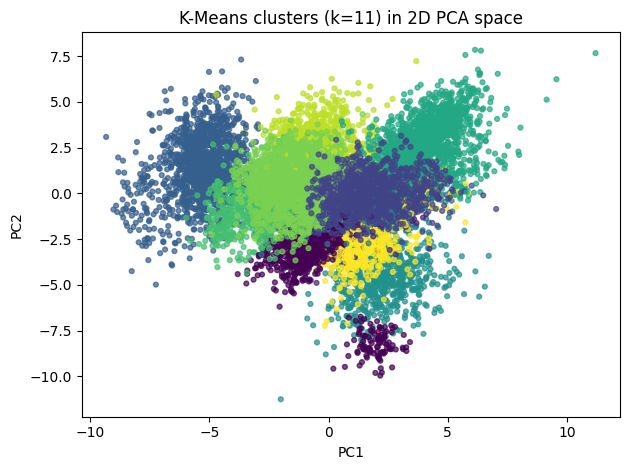

Explained variance by 2D PCA (for plot): 0.3383
ARI: 0.34432192018938046
NMI: 0.5537162107927416


In [55]:
kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE)
km_labels = kmeans.fit_predict(X)

km_metrics = clustering_metrics(X, km_labels)
km_purity, km_ct = cluster_purity(y_true, km_labels)

print("KMeans metrics:", km_metrics)
print("KMeans purity:", km_purity)

display(km_ct)

expl2 = plot_pca_2d(X, km_labels, f"K-Means clusters (k={best_k}) in 2D PCA space")
print("Explained variance by 2D PCA (for plot):", round(expl2, 4))

# Optional: external metrics (analysis only)
print("ARI:", adjusted_rand_score(y_true, km_labels))
print("NMI:", normalized_mutual_info_score(y_true, km_labels))


## 5) Second algorithm: Agglomerative (Hierarchical) — sweep k

The assignment asks for **at least two** algorithms. We'll run **Agglomerative** here.


In [56]:
agg_results = []
for k in K_RANGE:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_agg = agg.fit_predict(X)

    m = clustering_metrics(X, labels_agg)
    purity, _ = cluster_purity(y_true, labels_agg)
    agg_results.append({
        "k": k,
        **m,
        "purity": purity
    })

agg_df = pd.DataFrame(agg_results)
agg_df


,k,silhouette,calinski_harabasz,davies_bouldin,purity
0,2,0.131425,1569.613797,2.551652,0.473277
1,3,0.125285,1432.548043,2.098270,0.473277
2,4,0.156812,1400.818009,1.981225,0.592149
3,5,0.169419,1424.051285,1.992979,0.637210
4,6,0.183501,1432.044858,1.881086,0.695356
5,7,0.193128,1350.936352,1.793724,0.695356
6,8,0.189917,1287.176339,1.768446,0.775065
7,9,0.196520,1248.825951,1.690855,0.828327
8,10,0.205956,1215.114763,1.647415,0.850534
9,11,0.214448,1191.457036,1.557060,0.850534


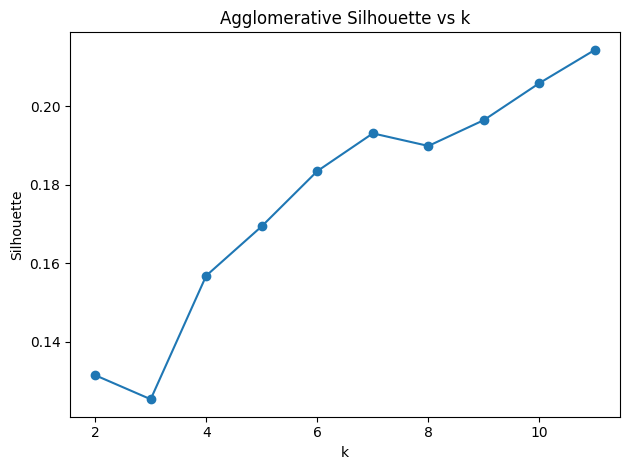

Best k (Agglomerative) by silhouette: 11


In [57]:
plt.figure()
plt.plot(agg_df["k"], agg_df["silhouette"], marker="o")
plt.title("Agglomerative Silhouette vs k")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

best_k_agg = int(agg_df.loc[agg_df["silhouette"].idxmax(), "k"])
print("Best k (Agglomerative) by silhouette:", best_k_agg)


Agglomerative metrics: {'silhouette': 0.2144479913904449, 'calinski_harabasz': 1191.4570364582576, 'davies_bouldin': 1.5570599695309704}
Agglomerative purity: 0.8505344636933284


label,German,Italian,Korean,Spanish
cluster,,,,
0,688,4,1323,6
1,677,9,9,436
2,44,1284,420,1
3,0,0,0,1290
4,0,965,0,0
5,687,0,0,0
6,0,584,0,0
7,0,0,865,0
8,579,1,0,0


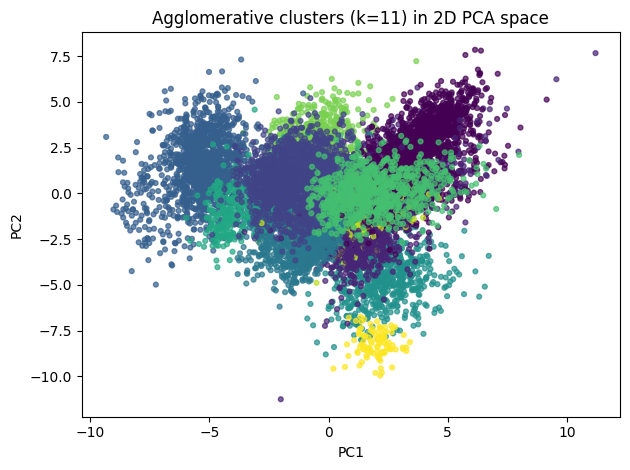

Explained variance by 2D PCA (for plot): 0.3383
ARI: 0.3590079715725238
NMI: 0.5891608773584703


In [58]:
agg = AgglomerativeClustering(n_clusters=best_k_agg, linkage="ward")
agg_labels = agg.fit_predict(X)

agg_metrics = clustering_metrics(X, agg_labels)
agg_purity, agg_ct = cluster_purity(y_true, agg_labels)

print("Agglomerative metrics:", agg_metrics)
print("Agglomerative purity:", agg_purity)

display(agg_ct)

expl2 = plot_pca_2d(X, agg_labels, f"Agglomerative clusters (k={best_k_agg}) in 2D PCA space")
print("Explained variance by 2D PCA (for plot):", round(expl2, 4))

print("ARI:", adjusted_rand_score(y_true, agg_labels))
print("NMI:", normalized_mutual_info_score(y_true, agg_labels))


## 6) Gaussian Mixture Model (GMM) — choose k via BIC/AIC

GMM is a soft clustering method that can capture elliptical clusters.


,k,bic,aic,silhouette,calinski_harabasz,davies_bouldin,purity
0,2,842047.720143,833873.270803,0.137045,1717.535426,2.443640,0.463878
1,3,816310.414988,804045.094926,0.139943,1516.468354,2.286761,0.582750
2,4,786401.120874,770044.930091,0.158558,1506.286690,2.002014,0.648913
3,5,748126.506680,727679.445175,0.161609,1378.749711,2.059730,0.578327
4,6,725321.076510,700783.144283,0.170192,1446.827744,1.904230,0.647070
5,7,714093.276087,685464.473138,0.178944,1329.159651,1.917431,0.790085
6,8,722088.036975,689368.363304,0.160357,1173.269501,2.194361,0.680612
7,9,711287.865769,674477.321376,0.167729,1153.080725,2.153221,0.775986
8,10,704230.854918,663329.439803,0.176255,1141.214202,2.018541,0.797917
9,11,697305.482259,652313.196422,0.181278,1119.633561,1.915204,0.800590


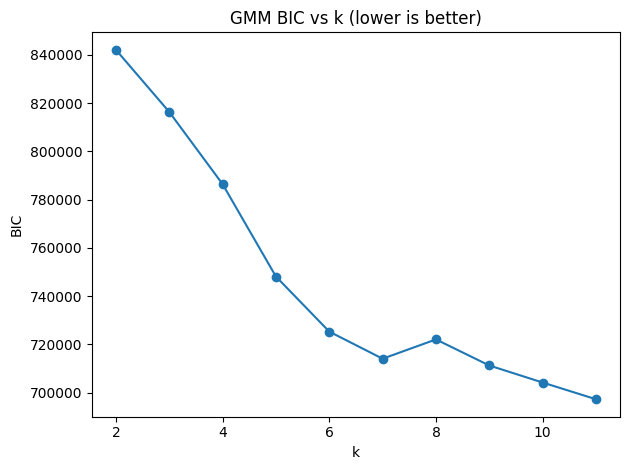

In [ ]:
gmm_rows = []
for k in K_RANGE:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=RANDOM_STATE)
    gmm.fit(X)
    labels_gmm = gmm.predict(X)
    m = clustering_metrics(X, labels_gmm)
    purity, _ = cluster_purity(y_true, labels_gmm)
    gmm_rows.append({
        "k": k,
        "bic": gmm.bic(X),
        "aic": gmm.aic(X),
        **m,
        "purity": purity
    })

gmm_df = pd.DataFrame(gmm_rows)
display(gmm_df)

plt.figure()
plt.plot(gmm_df["k"], gmm_df["bic"], marker="o")
plt.title("GMM BIC vs k (lower is better)")
plt.xlabel("k")
plt.ylabel("BIC")
plt.tight_layout()
plt.show()


## 7) DBSCAN — density based

DBSCAN finds dense regions and marks outliers as noise (-1).  
You typically need to tune `eps` and `min_samples`.


In [60]:
# Uncomment if you want DBSCAN
# db = DBSCAN(eps=3.2, min_samples=5)
# db_labels = db.fit_predict(X)

# db_metrics = clustering_metrics(X, db_labels)
# db_purity, db_ct = cluster_purity(y_true, db_labels)

# print("DBSCAN metrics:", db_metrics)
# print("DBSCAN purity:", db_purity)
# print("Clusters (including noise):", np.unique(db_labels))

# display(db_ct)
# _ = plot_pca_2d(X, db_labels, "DBSCAN clusters in 2D PCA space (noise=-1)")


## 8) Compare algorithms (Silhouette + Purity)

Silhouette is the required metric; purity/composition is required for discussion.


In [61]:
summary = pd.DataFrame([
    {
        "algorithm": f"KMeans (k={best_k})",
        "silhouette": km_metrics["silhouette"],
        "calinski_harabasz": km_metrics["calinski_harabasz"],
        "davies_bouldin": km_metrics["davies_bouldin"],
        "purity": km_purity,
    },
    {
        "algorithm": f"Agglomerative (k={best_k_agg})",
        "silhouette": agg_metrics["silhouette"],
        "calinski_harabasz": agg_metrics["calinski_harabasz"],
        "davies_bouldin": agg_metrics["davies_bouldin"],
        "purity": agg_purity,
    },
]).sort_values(by="silhouette", ascending=False)

summary


,algorithm,silhouette,calinski_harabasz,davies_bouldin,purity
0,KMeans (k=11),0.222257,1259.777074,1.59066,0.851548
1,Agglomerative (k=11),0.214448,1191.457036,1.55706,0.850534


## 9) Save cluster assignments

This makes it easy to include cluster IDs in your report or further analysis.


In [62]:
out = df[[label_col]].copy()
if "filename" in df.columns:
    out["filename"] = df["filename"]
if "gender" in df.columns:
    out["gender"] = df["gender"]

out["cluster_kmeans"] = km_labels
out["cluster_agglomerative"] = agg_labels

out_path = Path("cluster_assignments.csv")
out.to_csv(out_path, index=False)
print("Saved:", out_path.resolve())
out.head()


Saved: C:\UT university\Machine Learning\project\phase 2\cluster_assignments.csv


,label,filename,gender,cluster_kmeans,cluster_agglomerative
0,German,810100147_male_german_voice02.mp3,Male,5,5
1,German,810100147_male_german_voice02.mp3,Male,5,5
2,German,810100147_male_german_voice02.mp3,Male,5,5
3,German,810100147_male_german_voice02.mp3,Male,5,5
4,German,810100147_male_german_voice02.mp3,Male,5,5
